In [1]:
# imports

import os, re, json, pickle, torch
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix # should i add classification report somewhere
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

# model 1 - rf
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

# model 2 - bert
from torch.utils.data import Dataset, DataLoader 
from transformers import BertTokenizer, BertModel, BertForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm

# model 3 - hybrid 
import optuna

# model 4 - lstm 
from torch.nn.utils.rnn import pad_sequence
from collections import Counter

# Suppress minor warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)

### classes

In [2]:
# includes data processing, EDA functions, etc. 

class MovieWorkflowManager:
    def __init__(self):
        self.base_path = os.getcwd() 
        self.folders = {
            "audience-reviews":      {"type": "audience", "platform": "rt"},
            "critic-reviews-rt":        {"type": "critic",   "platform": "rt"},
            "audience-reviews-imdb": {"type": "audience", "platform": "imdb"},
            # "critic-reviews-metacritic": {"type": "critic",   "platform": "metacritic"}
        }
        self.stats = {"scraped_files": 0, "dropped_no_finance": 0, "final_movies": 0}

    def clean_val(self, v):
        if pd.isna(v) or v == "N/A": return np.nan
        s = re.sub(r'[^\d.]', '', str(v))
        return float(s) if s else np.nan

    def slugify(self, filename):
        name = os.path.splitext(filename)[0].lower()
        for term in ["reviews", "imdb", "rt", "roger", "ebert", "metadata", "audience", "critic"]:
            name = name.replace(term, "")
        return name.strip("_")

    def load_master_metadata(self):
        meta_list = []

        for folder in self.folders.keys():
            path = os.path.join(self.base_path, folder)

            if not os.path.exists(path): 
                continue

            meta_files = [f for f in os.listdir(path) if "metadata" in f.lower() and f.endswith(".csv")]

            for mf in meta_files:
                temp_df = pd.read_csv(os.path.join(path, mf))
                temp_df.columns = [c.lower().strip() for c in temp_df.columns]

                key_col = 'movie_key' if 'movie_key' in temp_df.columns else temp_df.columns[0]
                temp_df['movie_key_clean'] = temp_df[key_col].apply(self.slugify)
                meta_list.append(temp_df[['movie_key_clean', 'budget', 'gross_us', 'year']])
        
        master = pd.concat(meta_list).drop_duplicates(subset=['movie_key_clean'])
        master['budget'] = master['budget'].apply(self.clean_val)
        master['gross'] = master['gross_us'].apply(self.clean_val)
        return master.dropna(subset=['budget', 'gross']).set_index('movie_key_clean')
    
    def standardize_score(self, val, platform):
        if pd.isna(val) or val == "": return np.nan
        val_str = str(val).split('/')[0].replace('%', '').strip()
        try:
            score = float(val_str)
        except ValueError:
            return np.nan

        # platform specific
        if platform == "imdb":
            return score / 10.0
        
        if platform == "rt":
            if score > 10:
                return score / 100.0
            if score <= 5: 
                return score / 5.0
            return score / 10.0
            
        return score 

    def run_full_extraction(self): # figure out if this is for other sources too 
            master_meta = self.load_master_metadata()
            all_data = []

            for folder, info in self.folders.items():
                path = os.path.join(self.base_path, folder)
                if not os.path.exists(path): continue
                files = [f for f in os.listdir(path) if f.endswith(".csv") and "metadata" not in f.lower()]
                
                for f in files:
                    self.stats["scraped_files"] += 1
                    key = self.slugify(f)
                    
                    if key in master_meta.index:
                        m = master_meta.loc[key]
                        rdf = pd.read_csv(os.path.join(path, f))
                        rdf.columns = [c.lower().strip() for c in rdf.columns]
                        
                        score_col = None
                        for col in ['user_rating', 'score', 'rating', 'stars', 'user rating']:
                            if col in rdf.columns:
                                score_col = col
                                break
                        
                        if score_col:
                            rdf['user_rating'] = rdf[score_col].apply(
                                lambda x: self.standardize_score(x, info['platform'])
                            )
                        else:
                            rdf['user_rating'] = np.nan
                        
                        rdf['movie_title'] = key
                        rdf['budget'] = m['budget']
                        rdf['gross'] = m['gross']
                        rdf['year'] = m['year']
                        rdf['is_critic'] = 1 if info['type'] == "critic" else 0
                        all_data.append(rdf)
                    else:
                        self.stats["dropped_no_finance"] += 1
            
            full_df = pd.concat(all_data, ignore_index=True)
            full_df['label'] = (full_df['gross'] / full_df['budget'] >= 3.0).astype(int)
            self.stats["final_movies"] = full_df['movie_title'].nunique()
            return full_df
    
    def run_eda_visuals(self, df):
        print("Exploratory Data Analysis")

        print(f"Total Review Files Scraped: {self.stats['scraped_files']}")
        print(f"Files Dropped (no budget info): {self.stats['dropped_no_finance']}")
        print(f"Final Unique Movies in Study: {self.stats['final_movies']}")
        
        # survival bar chart
        plt.figure(figsize=(8, 4))
        sns.barplot(x=['Scraped', 'Valid (Financials)'], 
                    y=[self.stats['scraped_files'], self.stats['final_movies']], palette="mako")
        plt.title("Data Survival Comparison")
        plt.ylabel("Count of Movies")
        plt.show()

        # audience vs. critic plot
        temp_df = df.dropna(subset=['user_rating']).copy()
        
        # column 0 = audience, column 1 = critic
        corr_data = temp_df.groupby(['movie_title', 'is_critic'])['user_rating'].mean().unstack()

        # drop rows that don't have both audience and critic score 
        if corr_data.shape[1] >= 2:
            corr_plot_data = corr_data.dropna(subset=[0, 1])
            
            if not corr_plot_data.empty:
                plt.figure(figsize=(7, 7))
                sns.regplot(x=corr_plot_data[0], y=corr_plot_data[1], 
                            scatter_kws={'alpha':0.5, 'color':'teal'}, 
                            line_kws={'color':'red'})
                plt.xlabel("Average Audience Rating")
                plt.ylabel("Average Critic Rating")
                plt.title("Psychological Alignment: Audience vs. Critic")
                plt.grid(True, alpha=0.3)
                plt.show()
                
                r_val = corr_plot_data[0].corr(corr_plot_data[1])
                print(f"Sentiment Correlation Coefficient: {r_val:.2f}")
            else:
                print("Warning: No movies have both Audience and Critic ratings. Check your data folders.")
        else:
            print(f"Warning: Only one 'is_critic' type found. Available types: {corr_data.columns.tolist()}")


    def generate_trials(self, df):
        clean_df = df.dropna(subset=['review_text']).copy()
        trial_a = clean_df.copy()
        
        trial_b = clean_df.groupby('movie_title').agg({
            'review_text': lambda x: " [SEP] ".join(str(i) for i in x.fillna("")[:10]),
            'budget': 'first',
            'year': 'first',
            'label': 'first',
            'user_rating': 'mean',
            'is_critic': 'mean'
        }).reset_index()
        
        return trial_a, trial_b
    
    def compare_trials_initially(self, t_a, t_b):
        feats   = ['user_rating', 'year']
        trials  = [("Trial A (Individual)", t_a), ("Trial B (Collective)", t_b)]
        results = {}

        # fit rf on each trial -> why do we need to do this 
        for name, df in trials:
            existing_feats = [f for f in feats if f in df.columns]
            temp_df = df.dropna(subset=existing_feats + ['label'])

            print(f"Checking {name}: {len(temp_df)} rows found with valid features.")
            if len(temp_df) == 0:
                print(f"Skipping {name} — 0 rows after dropping NaNs.")
                continue

            X = temp_df[existing_feats]
            y = temp_df['label']

            gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
            try:
                train_idx, test_idx = next(gss.split(X, y, groups=temp_df['movie_title']))
            except Exception as e:
                print(f"Error splitting {name}: {e}")
                continue

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            rf = RandomForestClassifier(n_estimators=100, random_state=42)
            rf.fit(X_train, y_train)

            preds      = rf.predict(X_test)
            proba      = rf.predict_proba(X_test)[:, 1]
            acc        = accuracy_score(y_test, preds)
            f1         = f1_score(y_test, preds, average='weighted')
            cm         = confusion_matrix(y_test, preds)
            fpr, tpr, _ = roc_curve(y_test, proba)
            roc_auc    = auc(fpr, tpr)

            results[name] = {
                "Accuracy": acc, "F1-Score": f1,
                "cm": cm, "fpr": fpr, "tpr": tpr, "auc": roc_auc,
                "y_test": y_test, "df_full": temp_df,
            }
            print(f"{name} Results")
            print(f"Accuracy: {acc:.3f} | F1-Score: {f1:.3f} | AUC: {roc_auc:.3f}\n")

        if not results:
            print("No results to plot.")
            return None

        colors  = {"Trial A (Individual)": "#2ecc71", "Trial B (Collective)": "#e74c3c"}
        names   = list(results.keys())

        # plot 1: class balance 
        fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
        fig.suptitle("Plot 1 - Class Balance: Hit/Flop Distribution per Trial",
                     fontsize=13, fontweight='bold')

        for ax, (name, res) in zip(axes, results.items()):
            label_counts = res["df_full"]['label'].value_counts().sort_index()
            flop_count = label_counts.get(0, 0)
            hit_count  = label_counts.get(1, 0)
            total      = label_counts.sum()

            bar_flop = ax.bar('Flop (0)', flop_count, color=colors[name],
                              alpha=1.0, edgecolor='white')
            bar_hit  = ax.bar('Hit (1)',  hit_count,  color=colors[name],
                              alpha=0.55, edgecolor='white')

            for bar, count in zip([bar_flop[0], bar_hit[0]], [flop_count, hit_count]):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + total * 0.01,
                    f"{count}\n({count/total:.0%})",
                    ha='center', va='bottom', fontsize=10
                )
                
            ax.set_title(name)
            ax.set_ylabel("Row Count")
            ax.set_ylim(0, total * 1.2)
            sns.despine(ax=ax)

        plt.tight_layout()
        plt.show()

        # plot 2: side by side accuracy
        fig, ax = plt.subplots(figsize=(8, 5))
        fig.suptitle("Plot 2 — Accuracy & F1-Score",
                     fontsize=13, fontweight='bold')

        x        = range(len(names))
        width    = 0.35
        accs     = [results[n]["Accuracy"] for n in names]
        f1s      = [results[n]["F1-Score"] for n in names]
        bar_cols = [colors[n] for n in names]

        bars_acc = ax.bar([i - width/2 for i in x], accs, width,
                          label='Accuracy', color=bar_cols, alpha=0.9, edgecolor='white')
        bars_f1  = ax.bar([i + width/2 for i in x], f1s,  width,
                          label='F1-Score', color=bar_cols, alpha=0.55, edgecolor='white')

        for bar in list(bars_acc) + list(bars_f1):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha='center', va='bottom', fontsize=9
            )

        ax.set_xticks(list(x))
        ax.set_xticklabels(names)
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.0)
        ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Chance baseline')
        ax.legend()
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.show()

        # plot 3: confusion matrices 
        fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
        fig.suptitle("Plot 3 — Confusion Matrices",
                     fontsize=13, fontweight='bold')

        if len(results) == 1:
            axes = [axes]

        economic_labels = [
            ["True Negative", "False Positive"],
            ["False Negative", "True Positive"],
        ]

        for ax, (name, res) in zip(axes, results.items()):
            cm = res["cm"]
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Predicted Flop', 'Predicted Hit'],
                yticklabels=['Actual Flop',    'Actual Hit']
            )
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j + 0.5, i + 0.78, economic_labels[i][j],
                            ha='center', va='center', fontsize=7.5, color='darkred')
            ax.set_title(name)

        plt.tight_layout()
        plt.show()

        # plot 4: ROC curves 
        fig, ax = plt.subplots(figsize=(7, 6))
        fig.suptitle("Plot 4 — ROC Curves: Threshold-Independent Separation Quality",
                     fontsize=13, fontweight='bold')

        for name, res in results.items():
            ax.plot(
                res["fpr"], res["tpr"],
                color=colors[name], linewidth=2,
                label=f"{name}  (AUC = {res['auc']:.3f})"
            )

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier')
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(loc='lower right')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.show()

        winner = max(results, key=lambda n: results[n]["F1-Score"])
        print(f"The more accurate data structure is: {winner}")
        return winner
    
# data loader for model 
class MovieDataset(Dataset):
    def __init__(self, texts, numeric, labels, tok):
        self.texts = texts
        self.numeric = torch.tensor(numeric, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.tok = tok
    
    def __len__(self): return len(self.labels)
    
    def __getitem__(self, i):
        e = self.tok(str(self.texts[i]), max_length=128, truncation=True, padding="max_length", return_tensors="pt")
        return {
            "ids": e["input_ids"].squeeze(0), 
            "mask": e["attention_mask"].squeeze(0), 
            "num": self.numeric[i], 
            "lab": self.labels[i]
        }

# unsure where to put this 
# economic confusion matrix 
def plot_economic_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (1,1):
        print("Warning: Only one class predicted, Confusion Matrix plot skipped.")
        return
        
    labels = [
        ["True Negative", "False Positive"],
        ["False Negative", "True Positive"]
    ]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Predicted Flop", "Predicted Hit"],
                yticklabels=["Actual Flop", "Actual Hit"])
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j+0.5, i+0.7, labels[i][j], ha='center', va='center', fontsize=10, color='darkred')
            
    plt.title(title)
    plt.show()

### evaluate trial A and B 

Exploratory Data Analysis
Total Review Files Scraped: 474
Files Dropped (no budget info): 97
Final Unique Movies in Study: 199


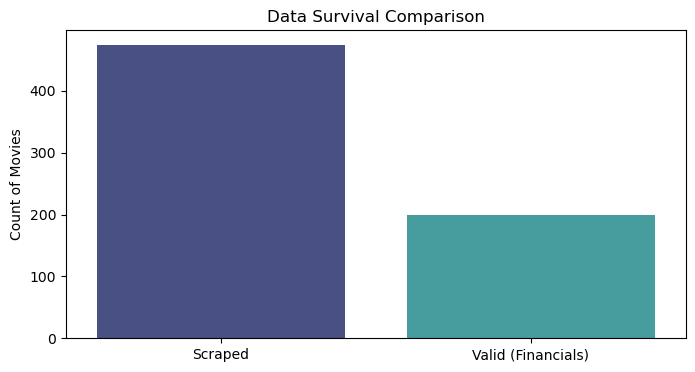

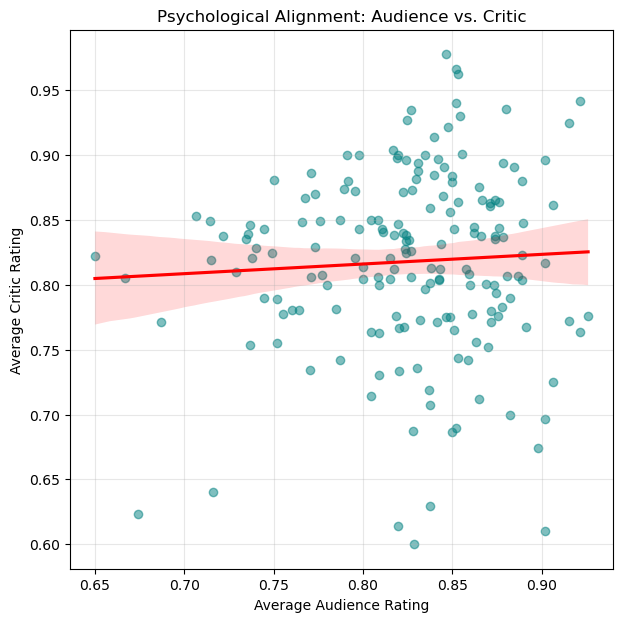

Sentiment Correlation Coefficient: 0.06
Checking Trial A (Individual): 12581 rows found with valid features.
Trial A (Individual) Results
Accuracy: 0.513 | F1-Score: 0.547 | AUC: 0.441

Checking Trial B (Collective): 191 rows found with valid features.
Trial B (Collective) Results
Accuracy: 0.534 | F1-Score: 0.561 | AUC: 0.455



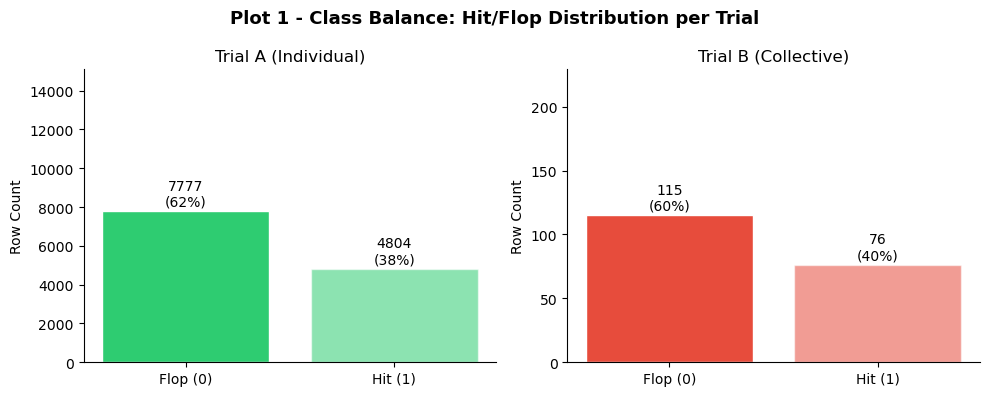

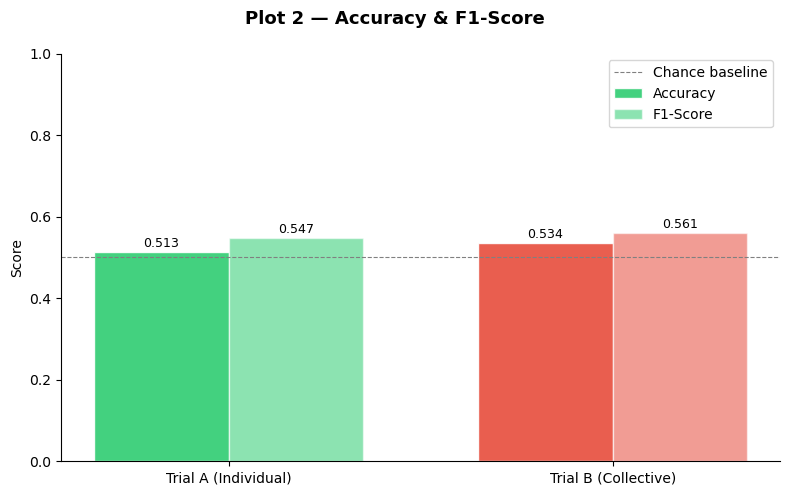

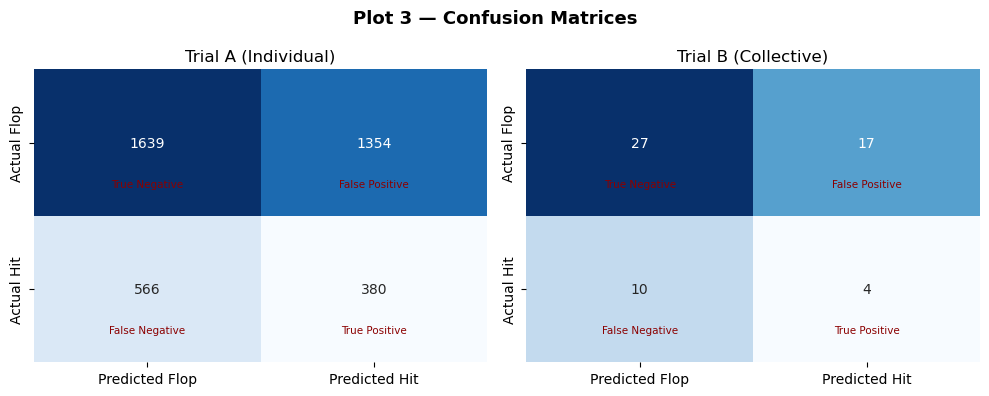

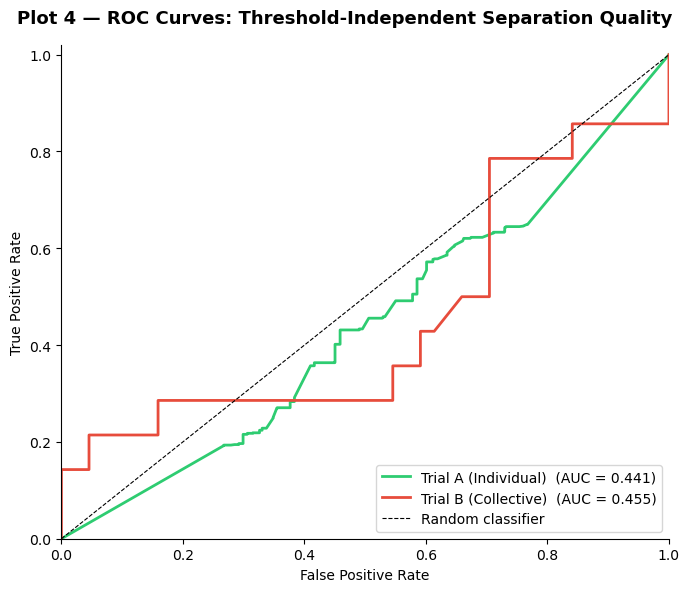

The more accurate data structure is: Trial B (Collective)


In [3]:
# execution 

# intialize and extract 
manager = MovieWorkflowManager()
full_dataset = manager.run_full_extraction()

# run eda 
manager.run_eda_visuals(full_dataset)

# generate trials
trial_a, trial_b = manager.generate_trials(full_dataset)
winning_trial_name = manager.compare_trials_initially(trial_a, trial_b)

In [4]:
# Select Trial B for training volume
df_final = trial_b

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df_final, groups=df_final['movie_title']))
train_df, test_df = df_final.iloc[train_idx].copy(), df_final.iloc[test_idx].copy()

numeric_feats = ['user_rating', 'budget']

Running Model 1: Random Forest...
Model 1 - Random Forest F1-Score: 0.552



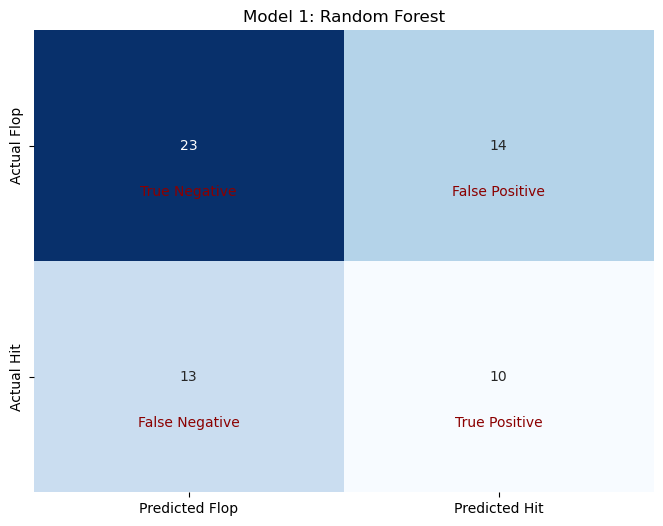

In [5]:
# model 1: random forest (numeric baseline)
print("Running Model 1: Random Forest...")

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_test_num = scaler.transform(test_df[numeric_feats].fillna(0))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_num, train_df['label'])

m1_preds = rf_model.predict(X_test_num)
m1_f1 = f1_score(test_df['label'], m1_preds, average='weighted')

print(f"Model 1 - Random Forest F1-Score: {m1_f1:.3f}\n")
plot_economic_matrix(test_df['label'], m1_preds, "Model 1: Random Forest")

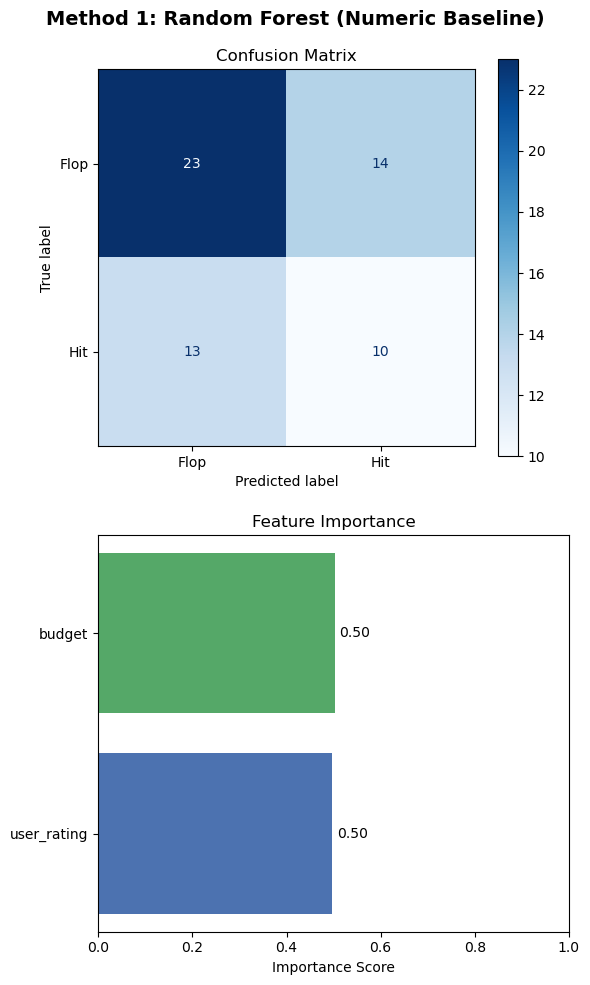

In [6]:
# visualization: confusion matrix and feature importance for model 1
fig, axes = plt.subplots(2, 1, figsize=(6, 10)) 
fig.suptitle("Method 1: Random Forest (Numeric Baseline)", fontsize=14, fontweight='bold')

# confusion matrix
ConfusionMatrixDisplay.from_predictions(
    test_df['label'], m1_preds,
    display_labels=["Flop", "Hit"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix")

# feature importance 
importances = rf_model.feature_importances_
axes[1].barh(numeric_feats, importances, color=["#4C72B0", "#55A868", "#C44E52"])
axes[1].set_xlabel("Importance Score")
axes[1].set_title("Feature Importance")
axes[1].set_xlim(0, 1)

for i, v in enumerate(importances):
    axes[1].text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

Using device for BERT: mps
Running Model 2: BERT...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training...


Epoch 1: 100%|██████████| 18/18 [00:18<00:00,  1.03s/it]


Epoch 1 average loss: 0.6800


Epoch 2: 100%|██████████| 18/18 [00:17<00:00,  1.05it/s]


Epoch 2 average loss: 0.6733
Evaluating...


Testing: 100%|██████████| 8/8 [00:06<00:00,  1.23it/s]


Method 2 - BERT F1-Score: 0.470


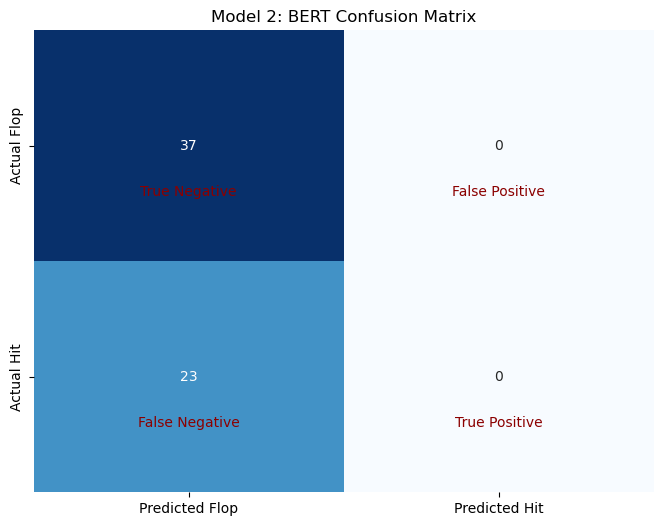

In [7]:
# model 2: bert (qualitative baseline)

# neural network 
class MovieClassifier(nn.Module):
    def __init__(self, n_dim, hidden_dim, dropout_prob):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # what does this do again 
        for n, p in self.bert.named_parameters():
            if "encoder.layer.10" not in n and "encoder.layer.11" not in n: 
                p.requires_grad = False

        self.num_bnch = nn.Sequential(
            nn.Linear(n_dim, 64), 
            nn.ReLU(),
            nn.Dropout(dropout_prob)
        )

        self.fusion = nn.Sequential(
            nn.Linear(768 + 64, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, ids, mask, num):
        t_f = self.bert(ids, mask).last_hidden_state[:, 0, :]
        n_f = self.num_bnch(num)
        return self.fusion(torch.cat([t_f, n_f], dim=1)).squeeze(1)

# set device -> do i need this
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available(): 
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device for BERT: {device}")

class SimpleTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        encoding = self.tokenizer(self.texts[i], truncation=True, padding='max_length', max_length=256, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[i], dtype=torch.long)
        }
    
print("Running Model 2: BERT...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
m2_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

# freeze all layers except top 2 
for name, param in m2_model.bert.named_parameters():
    if "encoder.layer.11" not in name and "encoder.layer.10" not in name:
        param.requires_grad = False

# prepare data loaders
train_ds = SimpleTextDataset(train_df['review_text'].tolist(), train_df['label'].tolist(), tokenizer)
test_ds = SimpleTextDataset(test_df['review_text'].tolist(), test_df['label'].tolist(), tokenizer)

train_loader_m2 = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader_m2 = DataLoader(test_ds, batch_size=8)

# optimizer
optimizer = AdamW(filter(lambda p: p.requires_grad, m2_model.parameters()), lr=2e-5)

# training loop
print("Starting training...")
m2_model.train()
for epoch in range(2): 
    total_loss = 0
    for batch in tqdm(train_loader_m2, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = m2_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1} average loss: {total_loss/len(train_loader_m2):.4f}")

# evaluation 
print("Evaluating...")
m2_model.eval()
m2_preds = []
with torch.no_grad():
    for batch in tqdm(test_loader_m2, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = m2_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        m2_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

m2_f1 = f1_score(test_df['label'], m2_preds, average='weighted')
print(f"\nMethod 2 - BERT F1-Score: {m2_f1:.3f}")
plot_economic_matrix(test_df['label'], m2_preds, "Model 2: BERT Confusion Matrix")

Running Model 3: Hybrid...


[I 2026-03-15 18:32:06,936] A new study created in memory with name: no-name-6c3826e3-b3a8-416d-a50a-877014ed49cb


Running hyperparameter tuning...


[I 2026-03-15 18:32:52,670] Trial 0 finished with value: 0.5072916666666667 and parameters: {'lr': 0.00024761818743861244, 'hidden_dim': 256, 'dropout': 0.46412289671057916, 'batch_size': 8}. Best is trial 0 with value: 0.5072916666666667.
[I 2026-03-15 18:33:36,997] Trial 1 finished with value: 0.40652486346651334 and parameters: {'lr': 0.0004369439869068884, 'hidden_dim': 512, 'dropout': 0.4343825518326228, 'batch_size': 8}. Best is trial 0 with value: 0.5072916666666667.
[I 2026-03-15 18:34:22,754] Trial 2 finished with value: 0.6027777777777777 and parameters: {'lr': 0.0004446046530320367, 'hidden_dim': 256, 'dropout': 0.45430404537551067, 'batch_size': 8}. Best is trial 2 with value: 0.6027777777777777.
[I 2026-03-15 18:35:08,718] Trial 3 finished with value: 0.5072916666666667 and parameters: {'lr': 0.0004932917605436328, 'hidden_dim': 512, 'dropout': 0.39663141836686916, 'batch_size': 8}. Best is trial 2 with value: 0.6027777777777777.
[I 2026-03-15 18:35:52,260] Trial 4 finishe

Epoch 1 | Loss: 0.6962
Epoch 2 | Loss: 0.7122
Epoch 3 | Loss: 0.6936
Model 3 - Hybrid F1-Score: 0.470


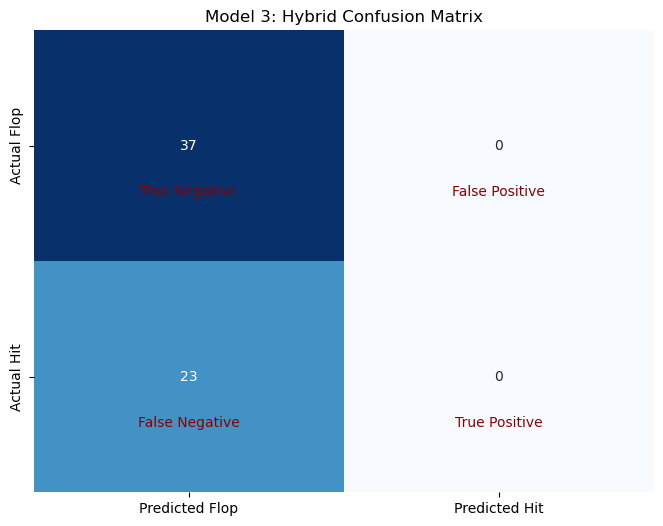

In [8]:
# model 3: hybrid model 

# hyperparameter tuner
def objective(trial, train_df, test_df, numeric_feats):
    lr = trial.suggest_float("lr", 0.0001, 0.001, log=True)
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    dropout_prob = trial.suggest_float("dropout", 0.2, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [8, 16])

    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[numeric_feats].fillna(0))
    X_test = scaler.transform(test_df[numeric_feats].fillna(0))
    
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    train_loader = DataLoader(MovieDataset(train_df['review_text'].tolist(), X_train, train_df['label'].tolist(), tokenizer), 
                           batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(MovieDataset(test_df['review_text'].tolist(), X_test, test_df['label'].tolist(), tokenizer), 
                          batch_size=batch_size)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    m3_model_trial = MovieClassifier(len(numeric_feats), hidden_dim, dropout_prob).to(device)
    
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, m3_model_trial.parameters()), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    m3_model_trial.train()
    for epoch in range(3): 
        for b in train_loader:
            optimizer.zero_grad()
            out = m3_model_trial(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
            loss = criterion(out, b["lab"].to(device))
            loss.backward()
            optimizer.step()

    m3_model_trial.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for b in test_loader:
            logits = m3_model_trial(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
            p = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
            preds.extend(p)
            actuals.extend(b["lab"].numpy())

    return f1_score(actuals, preds, average='weighted') # -> what is a weighted f-score 

def run_hyperparameter_tuning(train_df, test_df, numeric_feats, n_trials=10):
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, train_df, test_df, numeric_feats), n_trials=n_trials)

    return study.best_params

print("Running Model 3: Hybrid...")

numeric_feats = ['user_rating', 'budget']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# hyperparameter tuning
print("Running hyperparameter tuning...")
best_params_m3 = run_hyperparameter_tuning(train_df, test_df, numeric_feats, n_trials=5)
best_lr = best_params_m3['lr']
best_batch = best_params_m3['batch_size']
best_hidden_dim = best_params_m3['hidden_dim']

# scale numeric data
X_train_m3 = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_test_m3 = scaler.transform(test_df[numeric_feats].fillna(0))

# prepare data loaders
train_loader_m3 = DataLoader(
    MovieDataset(train_df['review_text'].tolist(), X_train_m3, train_df['label'].tolist(), tokenizer), 
    batch_size=best_batch, 
    shuffle=True
)
test_loader_m3 = DataLoader(
    MovieDataset(test_df['review_text'].tolist(), X_test_m3, test_df['label'].tolist(), tokenizer), 
    batch_size=best_batch
)

# initialize model
m3_model = MovieClassifier(
    n_dim=len(numeric_feats), 
    hidden_dim=best_params_m3['hidden_dim'], 
    dropout_prob=best_params_m3['dropout']
).to(device)
opt = AdamW(filter(lambda p: p.requires_grad, m3_model.parameters()), lr=best_lr)
crit = nn.BCEWithLogitsLoss()

# training loop
m3_model.train()
for ep in range(3):
    total_loss = 0
    for b in train_loader_m3:
        opt.zero_grad()
        out = m3_model(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
        loss = crit(out, b["lab"].to(device))
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {ep+1} | Loss: {total_loss/len(train_loader_m3):.4f}")

# evaluation
m3_model.eval()
m3_probs = []
with torch.no_grad(): 
    for b in test_loader_m3:
        logits = m3_model(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
        m3_probs.extend(torch.sigmoid(logits).cpu().numpy())

m3_preds = (np.array(m3_probs) >= 0.5).astype(int)
m3_f1 = f1_score(test_df['label'], m3_preds, average='weighted')
print(f"Model 3 - Hybrid F1-Score: {m3_f1:.3f}")
plot_economic_matrix(test_df['label'], m3_preds, "Model 3: Hybrid Confusion Matrix")

Running Model 4: Bidirectional LSTM
Running hyperparameter tuning:
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.5850
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.5443
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.5571
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.5233
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.6108
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.5401
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.6513
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.5197
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.5289
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.5571
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.5323
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.5323
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.4704
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.5912
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.5063
Testing: LR=0.001, Hidde

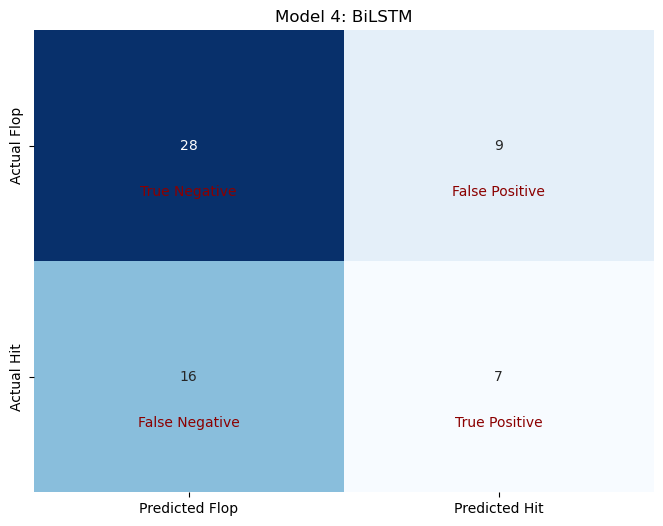

In [9]:
# model 4: biLSTM 

# functions 
def build_vocab(texts, max_vocab=10000):
    words = " ".join(texts).lower().split()
    count = Counter(words)

    vocab = {word: i+2 for i, (word, _) in enumerate(count.most_common(max_vocab))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1

    return vocab

def text_to_indices(text, vocab):
    return [vocab.get(word.lower(), 1) for word in str(text).split()]

# hyperparameter tuner
def tune_lstm(train_indices, train_labels, test_indices, test_labels, vocab, device):
    lrs = [0.001, 0.0005, 0.0001]
    hiddens = [64, 128, 256]
    dropouts = [0.2, 0.5]
    embed_dims = [100, 200, 300]
    
    best_f1 = 0
    best_params = {}

    # what is pad_sequence
    X_train = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    y_train = torch.tensor(train_labels.values, dtype=torch.float32).to(device)
    X_test = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    
    for lr in lrs:
        for hd in hiddens:
            for dr in dropouts:
                for ed in embed_dims:
                    print(f"Testing: LR={lr}, Hidden={hd}, Dropout={dr}")
                    model = MovieLSTM(len(vocab), ed, hd, dr).to(device) 
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                    criterion = nn.BCEWithLogitsLoss()
                    
                    model.train()
                    for epoch in range(5):
                        optimizer.zero_grad()
                        out = model(X_train)
                        loss = criterion(out, y_train)
                        loss.backward()
                        optimizer.step()
                    
                    model.eval()
                    with torch.no_grad():
                        logits = model(X_test)
                        preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
                        score = f1_score(test_labels, preds, average='weighted')
                    
                    print(f"Result F1: {score:.4f}")
                    if score > best_f1:
                        best_f1 = score
                        best_params = {'lr': lr, 'hidden': hd, 'dropout': dr, 'embed': ed} 
    
    return best_params

class MovieLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout_prob=0.3):
        super(MovieLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout_prob) 
        self.fc = nn.Linear(hidden_dim * 2, 1)
        
    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden_cat = self.dropout(hidden_cat) 
        return self.fc(hidden_cat).squeeze(1)

print("Running Model 4: Bidirectional LSTM")

vocab = build_vocab(train_df['review_text'])
train_indices = [torch.tensor(text_to_indices(t, vocab)) for t in train_df['review_text']]
test_indices = [torch.tensor(text_to_indices(t, vocab)) for t in test_df['review_text']]

# hyperparameter tuning
print("Running hyperparameter tuning:")
best_params_m4 = tune_lstm(train_indices, train_df['label'], test_indices, test_df['label'], vocab, device)

# data prep
X_train_m4 = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512]
X_test_m4 = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512]
y_train_m4 = torch.tensor(train_df['label'].values, dtype=torch.float32)

# training 
print(f"Training LSTM with: {best_params_m4}")
lstm_model = MovieLSTM(len(vocab), 128, best_params_m4['hidden'], best_params_m4['dropout']).to(device)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=best_params_m4['lr'])
criterion = nn.BCEWithLogitsLoss()

lstm_model.train()
for epoch in range(5): 
    optimizer.zero_grad()
    outputs = lstm_model(X_train_m4.to(device))
    loss = criterion(outputs, y_train_m4.to(device))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
    optimizer.step()
    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

# evaluation
lstm_model.eval()
with torch.no_grad():
    m4_logits = lstm_model(X_test_m4.to(device))
    m4_preds = (torch.sigmoid(m4_logits) >= 0.5).int().cpu().numpy()

m4_f1 = f1_score(test_df['label'], m4_preds, average='weighted')
print(f"\nModel 4 - BiLSTM F1-Score: {m4_f1:.3f}")
plot_economic_matrix(test_df['label'], m4_preds, "Model 4: BiLSTM")

Running Model 5: Hybrid BiLSTM...
Running hyperparameter tuning...
Testing: LR=0.001, Hidden=64, Dropout=0.2, Embed=100
Result F1: 0.4549
Testing: LR=0.001, Hidden=64, Dropout=0.2, Embed=200
Result F1: 0.5431
Testing: LR=0.001, Hidden=64, Dropout=0.3, Embed=100
Result F1: 0.6831
Testing: LR=0.001, Hidden=64, Dropout=0.3, Embed=200
Result F1: 0.5209
Testing: LR=0.001, Hidden=64, Dropout=0.5, Embed=100
Result F1: 0.4791
Testing: LR=0.001, Hidden=64, Dropout=0.5, Embed=200
Result F1: 0.6054
Testing: LR=0.001, Hidden=128, Dropout=0.2, Embed=100
Result F1: 0.5324
Testing: LR=0.001, Hidden=128, Dropout=0.2, Embed=200
Result F1: 0.5543
Testing: LR=0.001, Hidden=128, Dropout=0.3, Embed=100
Result F1: 0.4704
Testing: LR=0.001, Hidden=128, Dropout=0.3, Embed=200
Result F1: 0.5313
Testing: LR=0.001, Hidden=128, Dropout=0.5, Embed=100
Result F1: 0.5626
Testing: LR=0.001, Hidden=128, Dropout=0.5, Embed=200
Result F1: 0.5158
Testing: LR=0.0005, Hidden=64, Dropout=0.2, Embed=100
Result F1: 0.2852
Tes

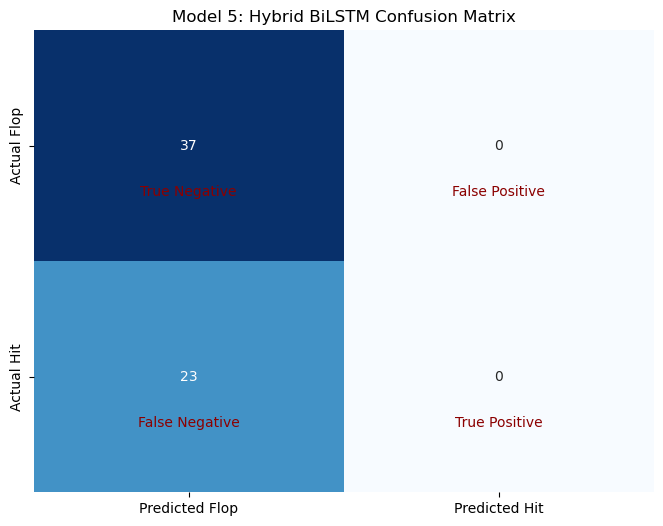

In [10]:
# model 5: hybrid biLSTM 

import copy
import random

def build_vocab(texts, max_vocab=10000):
    words = " ".join(texts).lower().split()
    count = Counter(words)
    vocab = {word: i+2 for i, (word, _) in enumerate(count.most_common(max_vocab))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

def text_to_indices(text, vocab):
    return [vocab.get(word.lower(), 1) for word in str(text).split()]

def tune_hybrid_bilstm(train_indices, train_numeric, train_labels, 
                     test_indices, test_numeric, test_labels, vocab, device):
    lrs = [0.001, 0.0005]
    hiddens = [64, 128]
    dropouts = [0.2, 0.3, 0.5]
    embed_dims = [100,200]

    best_f1 = 0 
    best_params = {}

    X_text_train = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    X_num_train = torch.tensor(train_numeric, dtype=torch.float32).to(device)
    y_train = torch.tensor(train_labels.values, dtype=torch.float32).to(device)

    X_text_test = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    X_num_test = torch.tensor(test_numeric, dtype=torch.float32).to(device)

    for lr in lrs:
            for hd in hiddens:
                for dr in dropouts:
                    for ed in embed_dims:
                        print(f"Testing: LR={lr}, Hidden={hd}, Dropout={dr}, Embed={ed}")
                        model = HybridBiLSTM(len(vocab), ed, hd, train_numeric.shape[1], dr).to(device) 
                        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                        criterion = nn.BCEWithLogitsLoss()
                        
                        model.train()
                        for epoch in range(5):
                            optimizer.zero_grad()

                            out = model(X_text_train, X_num_train)
                            loss = criterion(out, y_train)
                            loss.backward()
                            optimizer.step()
                        
                        model.eval()
                        with torch.no_grad():
                            logits = model(X_text_test, X_num_test)
                            preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
                            score = f1_score(test_labels, preds, average='weighted')
                        
                        print(f"Result F1: {score:.4f}")
                        if score > best_f1:
                            best_f1 = score
                            best_params = {'lr': lr, 'hidden': hd, 'dropout': dr, 'embed': ed} 
        
    return best_params

# neural network 
class HybridBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_numeric_feats, dropout_prob=0.3):
        super(HybridBiLSTM, self).__init__()
        
        # text branch 
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        
        # numeric branch 
        self.num_branch = nn.Sequential(
            nn.Linear(num_numeric_feats, 32),
            nn.ReLU()
        )

        self.dropout = nn.Dropout(dropout_prob)

        # fusion 
        self.fc = nn.Linear((hidden_dim * 2) + 32, 1)
        
    def forward(self, text, numeric):

        embedded = self.embedding(text)
        _, (hidden, _) = self.lstm(embedded)
        text_f = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        num_f = self.num_branch(numeric)
        
        combined = torch.cat((text_f, num_f), dim=1)
        combined = self.dropout(combined)
        return self.fc(combined).squeeze(1)

print("Running Model 5: Hybrid BiLSTM...")

vocab = build_vocab(train_df['review_text'])
train_indices = [torch.tensor(text_to_indices(t, vocab)) for t in train_df['review_text']]
test_indices = [torch.tensor(text_to_indices(t, vocab)) for t in test_df['review_text']]

numeric_feats = ['user_rating', 'budget']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_test_num = scaler.transform(test_df[numeric_feats].fillna(0))

# hyperparameter tuning
print("Running hyperparameter tuning...")
best_params_m5 = tune_hybrid_bilstm(train_indices, X_train_num, train_df['label'], 
                                  test_indices, X_test_num, test_df['label'], 
                                  vocab, device)

X_text_train_m5 = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512]
X_num_train_m5 = torch.tensor(X_train_num, dtype=torch.float32)
y_train_m5 = torch.tensor(train_df['label'].values, dtype=torch.float32)

X_text_test_m5 = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512]
X_num_test_m5 = torch.tensor(X_test_num, dtype=torch.float32)

# train model
print(f"Training Hybrid LSTM with: {best_params_m5}")
m5_model = HybridBiLSTM(len(vocab), 
                        best_params_m5['embed'], 
                        best_params_m5['hidden'], 
                        len(numeric_feats), 
                        best_params_m5['dropout']).to(device)
optimizer = torch.optim.Adam(m5_model.parameters(), lr=best_params_m5['lr'])
criterion = nn.BCEWithLogitsLoss()

# training loop
m5_model.train()
for epoch in range(5): 
    optimizer.zero_grad()

    outputs = m5_model(X_text_train_m5.to(device), X_num_train_m5.to(device))
    loss = criterion(outputs, y_train_m5.to(device))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(m5_model.parameters(), max_norm=1.0)
    optimizer.step()
    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

# evaluation
m5_model.eval()
with torch.no_grad():
    m5_logits = m5_model(X_text_test_m5.to(device), X_num_test_m5.to(device))
    m5_preds = (torch.sigmoid(m5_logits) >= 0.5).int().cpu().numpy()

m5_f1 = f1_score(test_df['label'], m3_preds, average='weighted')
print(f"Model 3 - Hybrid F1-Score: {m3_f1:.3f}")
plot_economic_matrix(test_df['label'], m3_preds, "Model 5: Hybrid BiLSTM Confusion Matrix")

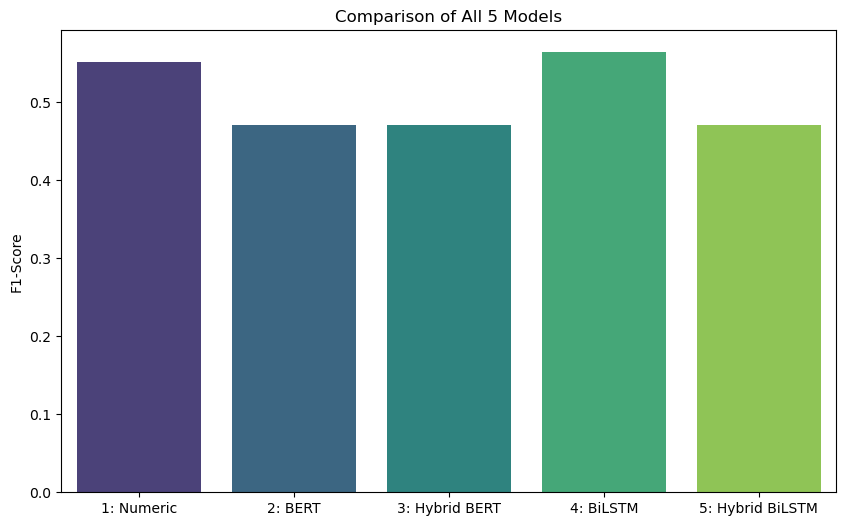

In [11]:
# model comparison chart
plt.figure(figsize=(10, 6))
methods = ['1: Numeric', '2: BERT', '3: Hybrid BERT', '4: BiLSTM', '5: Hybrid BiLSTM']
scores = [m1_f1, m2_f1, m3_f1, m4_f1, m5_f1]
sns.barplot(x=methods, y=scores, palette="viridis")
plt.title("Comparison of All 5 Models")
plt.ylabel("F1-Score")
plt.show()

### audience vs. critic usingt the best model

In [ ]:
class UnifiedDataset(Dataset):
    def __init__(self, texts, numeric, labels, tokenizer, vocab):
        self.texts = texts
        self.numeric = torch.tensor(numeric, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.tokenizer = tokenizer
        self.vocab = vocab
        
    def __len__(self): return len(self.labels)
    
    def __getitem__(self, i):
        # BERT tokens
        enc = self.tokenizer(str(self.texts[i]), max_length=128, truncation=True, padding="max_length", return_tensors="pt")
        
        # BiLSTM indices
        indices = torch.tensor(text_to_indices(str(self.texts[i]), self.vocab))
        
        # Pad indices manually to 256 for BiLSTM
        padded_indices = torch.zeros(256, dtype=torch.long)
        length = min(len(indices), 256)
        padded_indices[:length] = indices[:length]
        
        return {
            "bert_ids": enc["input_ids"].squeeze(0),
            "bert_mask": enc["attention_mask"].squeeze(0),
            "lstm_ids": padded_indices,
            "num": self.numeric[i],
            "lab": self.labels[i]
        }

def run_audience_critic_comparison(df): 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

    print(f"Starting Audience Critic Comparison on {device}...")

    # data prep
    df['review_text'] = df['review_text'].fillna("").astype(str)
    global_vocab = build_vocab(df['review_text'].tolist())
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    numeric_feats = ['user_rating', 'budget']
    
    # split cohorts
    cohorts = {
        "Audience": df[df['is_critic'] == 0].copy(),
        "Critic":   df[df['is_critic'] == 1].copy()
    }
    
    # storage for results
    model_names = ['RF (Num)', 'BERT (Text)', 'Hybrid BERT', 'BiLSTM (Text)', 'Hybrid BiLSTM']
    final_results = {m: {} for m in model_names}

    for c_name, c_df in cohorts.items():
        print(f"\nTesting Cohort: {c_name} ({len(c_df)} rows)")
        
        # standardize for this cohort
        scaler = StandardScaler()
        num_scaled = scaler.fit_transform(c_df[numeric_feats].fillna(0))
        
        # split
        gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        train_idx, test_idx = next(gss.split(c_df, c_df['label'], groups=c_df['movie_title']))
        
        train_df, test_df = c_df.iloc[train_idx], c_df.iloc[test_idx]
        X_num_train, X_num_test = num_scaled[train_idx], num_scaled[test_idx]

        # prepare data loaders
        train_ds = UnifiedDataset(train_df['review_text'].tolist(), X_num_train, train_df['label'].tolist(), tokenizer, global_vocab)
        test_ds = UnifiedDataset(test_df['review_text'].tolist(), X_num_test, test_df['label'].tolist(), tokenizer, global_vocab)
        
        train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=16)

        # model 1: random forest
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_num_train, train_df['label'])
        final_results['RF (Num)'][c_name] = f1_score(test_df['label'], rf.predict(X_num_test), average='weighted')

        # model 2: BERT
        m2 = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=1).to(device)
        for param in m2.bert.parameters():
            param.requires_grad = False
        opt2 = AdamW(filter(lambda p: p.requires_grad, m2.parameters()), lr=1e-3)

        # model 3: hybrid BERT
        m3 = MovieClassifier(len(numeric_feats), hidden_dim=256, dropout_prob=0.3).to(device)
        for param in m3.bert.parameters():
            param.requires_grad = False
        opt3 = AdamW(filter(lambda p: p.requires_grad, m3.parameters()), lr=1e-3)
        
        # model 4: biLSTM 
        m4 = MovieLSTM(len(global_vocab), 128, 64).to(device)
        opt4 = torch.optim.Adam(m4.parameters(), lr=0.001)

        # model 5: hybrid biLSTM
        m5 = HybridBiLSTM(len(global_vocab), 128, 64, len(numeric_feats)).to(device)
        opt5 = torch.optim.Adam(m5.parameters(), lr=0.001)

        crit = nn.BCEWithLogitsLoss()

        # training loop 
        print(f"Training models for {c_name}...")
        for epoch in range(3): 
            for b in train_loader:
                ids, mask, lstm_ids, num, lab = b['bert_ids'].to(device), b['bert_mask'].to(device), b['lstm_ids'].to(device), b['num'].to(device), b['lab'].to(device)
                
                # M2
                opt2.zero_grad(); out2 = m2(ids, attention_mask=mask).logits.squeeze(1); crit(out2, lab).backward(); opt2.step()
                # M3
                opt3.zero_grad(); out3 = m3(ids, mask, num); crit(out3, lab).backward(); opt3.step()
                # M4
                opt4.zero_grad(); out4 = m4(lstm_ids); crit(out4, lab).backward(); opt4.step()
                # M5
                opt5.zero_grad(); out5 = m5(lstm_ids, num); crit(out5, lab).backward(); opt5.step()

        # evaluation 
        m2.eval(); m3.eval(); m4.eval(); m5.eval()
        p2, p3, p4, p5 = [], [], [], []
        with torch.no_grad():
            for b in test_loader:
                ids, mask, lstm_ids, num = b['bert_ids'].to(device), b['bert_mask'].to(device), b['lstm_ids'].to(device), b['num'].to(device)

                p2.extend((torch.sigmoid(m2(ids, attention_mask=mask).logits.squeeze(1)) >= 0.5).int().cpu().numpy())
                p3.extend((torch.sigmoid(m3(ids, mask, num)) >= 0.5).int().cpu().numpy())
                p4.extend((torch.sigmoid(m4(lstm_ids)) >= 0.5).int().cpu().numpy())
                p5.extend((torch.sigmoid(m5(lstm_ids, num)) >= 0.5).int().cpu().numpy())

        final_results['BERT (Text)'][c_name] = f1_score(test_df['label'], p2, average='weighted')
        final_results['Hybrid BERT'][c_name] = f1_score(test_df['label'], p3, average='weighted')
        final_results['BiLSTM (Text)'][c_name] = f1_score(test_df['label'], p4, average='weighted')
        final_results['Hybrid BiLSTM'][c_name] = f1_score(test_df['label'], p5, average='weighted')

    # final comparison plot 
    plot_data = []
    for m in model_names:
        for c in ["Audience", "Critic"]:
            if c in final_results[m]:
                plot_data.append({"Model": m, "Source": c, "F1-Score": final_results[m][c]})
    
    res_df = pd.DataFrame(plot_data)
    if not res_df.empty:
        plt.figure(figsize=(12, 6))
        sns.barplot(data=res_df, x="Model", y="F1-Score", hue="Source", palette="magma")
        plt.title("F1-Score: Audience vs. Critic Influence Across Model Architectures")
        plt.ylim(0, 1.0)
        plt.grid(axis='y', alpha=0.3)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("No results to plot. Check data filtering.")

    return res_df

comparison_results = run_audience_critic_comparison(full_dataset)

Starting Audience Critic Comparison on cpu...

Testing Cohort: Audience (9925 rows)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training models for Audience...


KeyboardInterrupt: 

In [16]:
def run_final_phase_comparison(full_df):
    # 1. DROP ROWS WITHOUT BUDGET (Enforce your financial constraint)
    df = full_df.dropna(subset=['budget']).copy()
    
    # 2. FILTER FOR MOVIES THAT HAVE BOTH (Enforce your "intersection" constraint)
    # Get movies that have at least one audience entry
    aud_movies = set(df[df['is_critic'] == 0]['movie_title'].unique())
    # Get movies that have at least one critic entry
    crit_movies = set(df[df['is_critic'] == 1]['movie_title'].unique())
    
    # Only keep the intersection
    both_eligible = aud_movies.intersection(crit_movies)
    df_filtered = df[df['movie_title'].isin(both_eligible)].copy()
    
    print(f"Total Movies with both Audience/Critic data: {len(both_eligible)}")
    print(f"Total Review rows to process: {len(df_filtered)}")

    # 3. DEFINE THE THREE COHORTS
    cohort_data = {
        "Audience": df_filtered[df_filtered['is_critic'] == 0].copy(),
        "Critic":   df_filtered[df_filtered['is_critic'] == 1].copy(),
        "Combined": df_filtered.copy()
    }

    # Storage for the F1 scores
    model_names = ['RF (Num)', 'BERT (Text)', 'Hybrid BERT', 'BiLSTM (Text)', 'Hybrid BiLSTM']
    comparison_stats = {m: {} for m in model_names}

    # 4. RUN ANALYSIS FOR EACH COHORT
    for name, c_df in cohort_data.items():
        print(f"\nProcessing Cohort: {name}...")
        
        # Prepare numeric features for this specific cohort
        scaler = StandardScaler()
        # Ensure we fillna(0) just in case rating is missing, though budget is now guaranteed
        num_feats = ['user_rating', 'budget']
        X_num_scaled = scaler.fit_transform(c_df[num_feats].fillna(0))
        
        # Split data using GroupShuffleSplit (using your existing logic)
        gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        train_idx, test_idx = next(gss.split(c_df, c_df['label'], groups=c_df['movie_title']))
        
        train_df, test_df = c_df.iloc[train_idx], c_df.iloc[test_idx]
        X_num_train, X_num_test = X_num_scaled[train_idx], X_num_scaled[test_idx]

        # REUSE YOUR GLOBAL CLASS: UnifiedDataset
        # (Assuming tokenizer and global_vocab are already defined globally)
        train_ds = UnifiedDataset(train_df['review_text'].tolist(), X_num_train, train_df['label'].tolist(), tokenizer, global_vocab)
        test_ds = UnifiedDataset(test_df['review_text'].tolist(), X_num_test, test_df['label'].tolist(), tokenizer, global_vocab)
        
        train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=16)

        # REUSE YOUR GLOBAL MODELS
        # Initialize M1 (RF)
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_num_train, train_df['label'])
        comparison_stats['RF (Num)'][name] = f1_score(test_df['label'], rf.predict(X_num_test), average='weighted')

        # Initialize Neural Models (M2-M5)
        # Using the classes you've already defined globally
        m2 = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=1).to(device)
        m3 = MovieClassifier(num_numeric_feats=2).to(device) # Your Hybrid BERT class
        
        for param in m2.bert.parameters():
            param.requires_grad = False

        for param in m3.bert.parameters():
            param.requires_grad = False
        
        m4 = MovieLSTM(vocab_size=len(global_vocab)).to(device) # Your BiLSTM class
        m5 = HybridBiLSTM(vocab_size=len(global_vocab), num_feats=2).to(device) # Your Hybrid BiLSTM class

        

        # Set up optimizers (standardizing to 3 epochs as per your logic)
        optimizers = [
            AdamW(filter(lambda p: p.requires_grad, m2.parameters()), lr=1e-3),
            AdamW(filter(lambda p: p.requires_grad, m3.parameters()), lr=1e-3),
            torch.optim.Adam(m4.parameters(), lr=0.001),
            torch.optim.Adam(m5.parameters(), lr=0.001)
        ]
        models = [m2, m3, m4, m5]
        crit = nn.BCEWithLogitsLoss()

        # Training Loop
        for epoch in range(3):
            for b in train_loader:
                ids, mask, lstm_ids, num, lab = b['bert_ids'].to(device), b['bert_mask'].to(device), b['lstm_ids'].to(device), b['num'].to(device), b['lab'].to(device)
                
                # Train M2, M3, M4, M5
                for i, (m, opt) in enumerate(zip(models, optimizers)):
                    opt.zero_grad()
                    if i == 0: out = m(ids, attention_mask=mask).logits.squeeze(1) # M2
                    elif i == 1: out = m(ids, mask, num) # M3
                    elif i == 2: out = m(lstm_ids) # M4
                    else: out = m(lstm_ids, num) # M5
                    
                    loss = crit(out, lab)
                    loss.backward()
                    opt.step()

        # Evaluation Loop
        for m in models: m.eval()
        preds = {2: [], 3: [], 4: [], 5: []}
        
        with torch.no_grad():
            for b in test_loader:
                ids, mask, lstm_ids, num = b['bert_ids'].to(device), b['bert_mask'].to(device), b['lstm_ids'].to(device), b['num'].to(device)
                
                preds[2].extend((torch.sigmoid(m2(ids, attention_mask=mask).logits.squeeze(1)) >= 0.5).int().cpu().numpy())
                preds[3].extend((torch.sigmoid(m3(ids, mask, num)) >= 0.5).int().cpu().numpy())
                preds[4].extend((torch.sigmoid(m4(lstm_ids)) >= 0.5).int().cpu().numpy())
                preds[5].extend((torch.sigmoid(m5(lstm_ids, num)) >= 0.5).int().cpu().numpy())

        # Store results
        comparison_stats['BERT (Text)'][name] = f1_score(test_df['label'], preds[2], average='weighted')
        comparison_stats['Hybrid BERT'][name] = f1_score(test_df['label'], preds[3], average='weighted')
        comparison_stats['BiLSTM (Text)'][name] = f1_score(test_df['label'], preds[4], average='weighted')
        comparison_stats['Hybrid BiLSTM'][name] = f1_score(test_df['label'], preds[5], average='weighted')

    # 5. GENERATE FINAL PLOT
    plot_list = []
    for m_name, cohorts in comparison_stats.items():
        for c_name, score in cohorts.items():
            plot_list.append({"Model": m_name, "Source": c_name, "F1": score})
    
    result_df = pd.DataFrame(plot_list)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=result_df, x="Model", y="F1", hue="Source", palette="magma")
    plt.title("Comparison: Influence of Audience vs. Critic vs. Combined Data")
    plt.ylim(0, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    return result_df

comparison_results = run_audience_critic_comparison(full_dataset)

Starting Audience Critic Comparison on cpu...

Testing Cohort: Audience (9925 rows)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training models for Audience...


KeyboardInterrupt: 